# Geometric & Intensity Transformations


Apply classical image processing operations using Python and the `(PIL)` library. Complete both tasks and save your output images for comparison.


In [12]:
# Import the library
from PIL import Image 

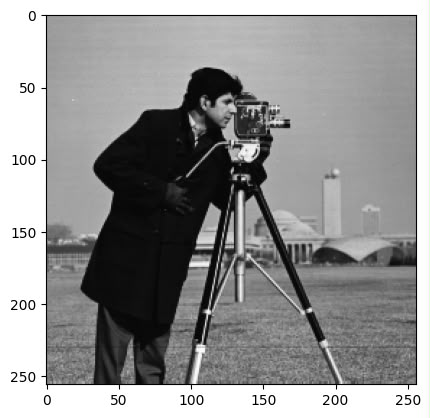

In [14]:
# ── Load image ────────────────────────────────────
img = Image.open("cameraman.png")
display(img)

### 1. Scale (increase size)
Double the image dimensions using `Image.resize()` with high-quality resampling `(LANCZOS)`.

In [21]:
# Get the size of the image
imgsize = (img.size) # first, I wanted to s=check the size of the image 
print("The size of the Image:", imgsize)
# scaling factors
scaledimg = img.resize( img.width // 2, img.height // 2)

The size of the Image: (430, 418)


Image size before scaling:  (430, 418)
Image size after scaling:  (860, 836)


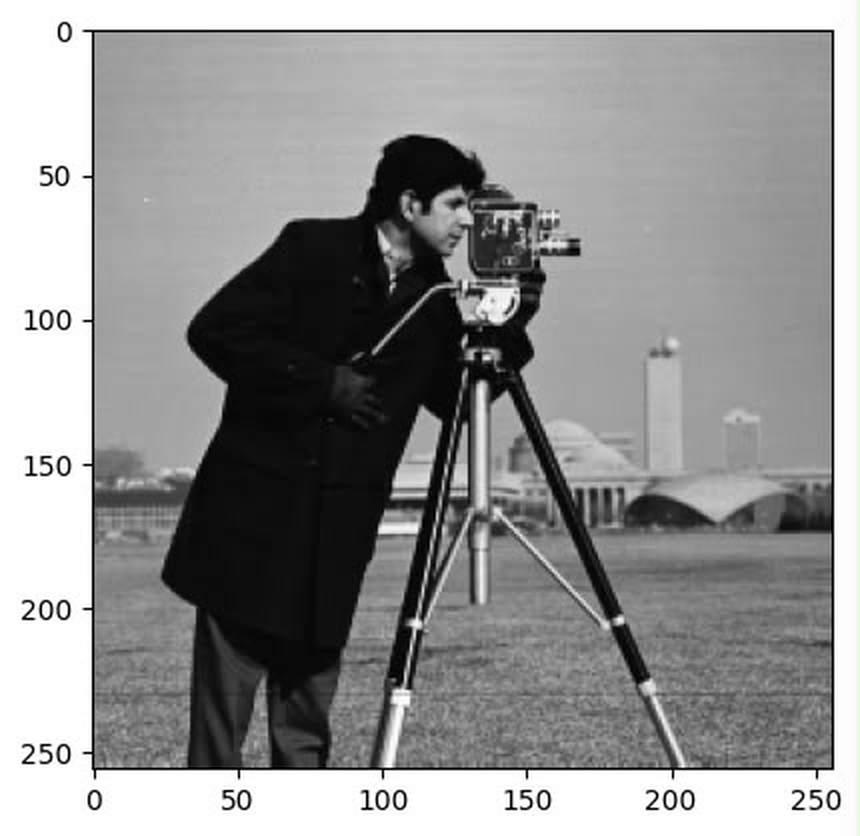

In [22]:
# ── 1. Increase size (scale ×2) ────────────────────

# Resize the image using PIL's built-in method
scalefactor = 2
newsize = (img.width * scalefactor, img.height * scalefactor)
newscale = img.resize(newsize, Image.LANCZOS)

print("Image size before scaling: ", img.size)
print("Image size after scaling: ", newscale.size)
display(newscale)


In [24]:

# Save the scaled image and print the sizes (The new image name should be "task1_1_scaled.jpg")
newscale.convert("RGB").save("task1_1_scaled.jpg")
print(f"Saved task1_1_scaled.jpg | original {img.size} -> scaled {newscale.size}")

Saved task1_1_scaled.jpg | original (430, 418) -> scaled (860, 836)


 non-uniform scale (cx=2, cy=1) → stretch horizontally only

In [25]:
cx, cy = 2, 1

ogwidth, ogheight = img.size
newwidth = int(ogwidth * cx)
newheight = int(ogheight * cy)

print(f"Original size:          ({ogwidth}, {ogheight})")
print(f"Non-uniform scaled size: ({newwidth}, {newheight})")

Original size:          (430, 418)
Non-uniform scaled size: (860, 418)


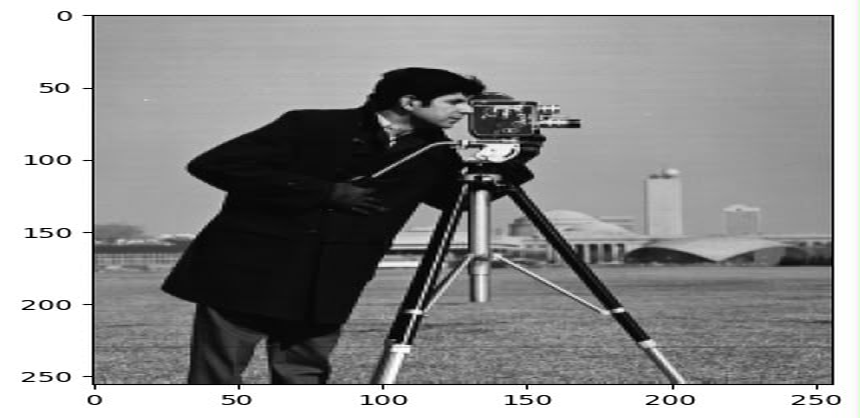

In [27]:
nonuniform = img.resize((newwidth, newheight), Image.LANCZOS)
display(nonuniform)

In [29]:
nonuniform.convert("RGB").save("task1_1b_nonuniform_scaled.jpg")
print(f"Saved task1_1b_nonuniform_scaled.jpg | size {nonuniform.size}")

Saved task1_1b_nonuniform_scaled.jpg | size (860, 418)


### 2. Rotate 120°
Rotate the image by 120 degrees, expanding the canvas to fit the full rotated image.

Original size: (430, 418)
Rotated size:  (578, 582)


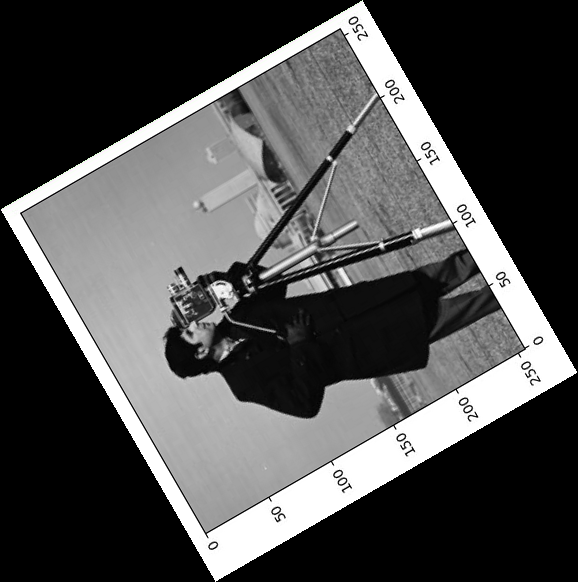

In [30]:
# ── 2. Rotate 120 degrees ──────────────────────────

rotated_img = img.rotate(120, expand=True, resample=Image.BICUBIC)

print("Original size:", img.size)
print("Rotated size: ", rotated_img.size)
display(rotated_img)


# Save the scaled image and print the sizes (The new image name should be "task1_2_rotated.jpg")

rotated_img.convert("RGB").save("task1_2_rotated.jpg")

### 3. Shear

In [31]:
# -- c. Get the image dimensions ────────────────────
width, height = img.size
print("Width:", width, "Height:", height)

Width: 430 Height: 418


In [32]:
# -- d. define the shear matrix ──────────────────────────
# Choose X-axis or Y-axis shear. The shear factor controls how much the image slants — start with 0.5 then experiment.
shear_factor = 0.5      # try 0.1, 0.3, 0.8 ...
axis = "x"               # "x" for X-axis shear, "y" for Y-axis shear

if axis == "x":
    shx, shy = shear_factor, 0
    # canvas must grow in width to fit the slanted image
    new_width = int(width + abs(shx) * height)
    new_height = height
else:
    shx, shy = 0, shear_factor
    # canvas must grow in height to fit the slanted image
    new_width = width
    new_height = int(height + abs(shy) * width)

print(f"Shear factor: {shear_factor} ({axis}-axis)")
print(f"New canvas size: ({new_width}, {new_height})")

Shear factor: 0.5 (x-axis)
New canvas size: (639, 418)


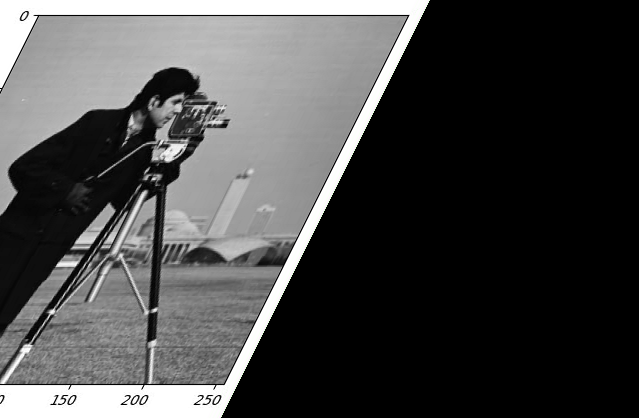

In [33]:
# -- e. Apply the shear transformation to the image ──────────────────────────
# PIL's transform() takes the inverse affine matrix:
# [ 1    shx   tx ]
# [ shy  1     ty ]

# Translation to keep the sheared image fully inside the new (larger) canvas
tx = -shx * height if shx < 0 else 0
ty = -shy * width if shy < 0 else 0

sheared_img = img.transform(
    (new_width, new_height),
    Image.AFFINE,
    (1, shx, tx, shy, 1, ty),
    resample=Image.BICUBIC
)
display(sheared_img)

In [34]:
# -- f. Save the sheared image(The new image name should be "task1_3_sheared.jpg") 
sheared_img.convert("RGB").save("task1_3_sheared.jpg")
print(f"Saved task1_3_sheared.jpg | size {sheared_img.size}")

Saved task1_3_sheared.jpg | size (639, 418)


### Experiment and compare
Try these:

— Change shear factor from 0.5 to 0.1, 0.3, 0.8 and compare results

— Switch from X-axis to Y-axis shear matrix

— Update the canvas multiplier to match your new factor

— Try combining X and Y shear in one matrix

# Intensity Transformations
Negative · Log · Power Law (Gamma)

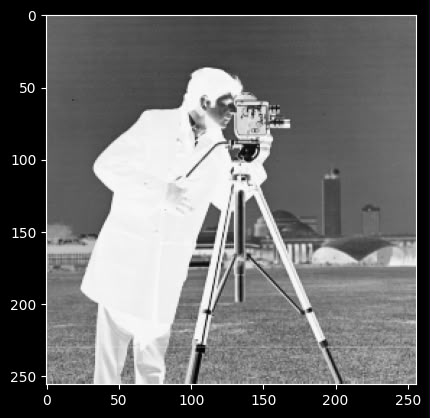

In [35]:

# ── 1. Negative ──────────────────────────────────── 
# Method 1: NumPy array manipulation
import numpy as np

img_array = np.array(img)
negative_array = 255 - img_array
negative_img = Image.fromarray(negative_array.astype(np.uint8))

display(negative_img)
negative_img.convert("RGB").save("task2_1_negative_numpy.jpg")

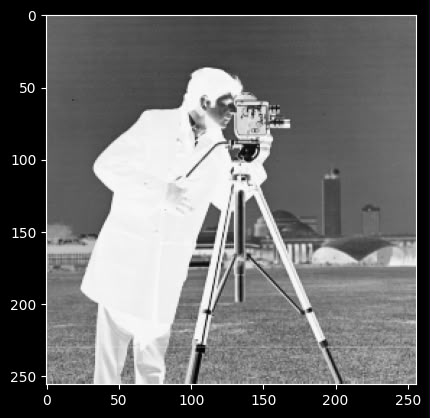

In [36]:
# Method 2: PIL's ImageOps
from PIL import ImageOps

negative_img_pil = ImageOps.invert(img.convert("RGB"))
display(negative_img_pil)
negative_img_pil.save("task2_1_negative_imageops.jpg")

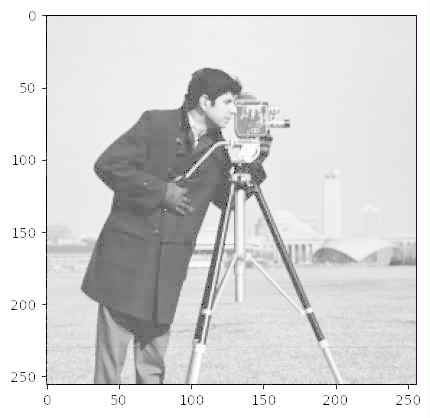

In [37]:
# ── 2. Log transformation ──────────────────────────

# s = c · log(1 + r) --> We need to find c.
# We want the maximum output value (s) to be 255 when the maximum input value (r) is 255:
# 255 = c · log(1 + 255)
# c = 255 / log(1 + 255)

img_array = np.array(img).astype(np.float64)   # cast to float first, or 1+255 overflows uint8!
c = 255 / np.log(1 + 255)

# Apply the log transformation to each pixel
log_array = c * np.log(1 + img_array)
log_array = np.clip(log_array, 0, 255).astype(np.uint8)

log_img = Image.fromarray(log_array)
display(log_img)
log_img.convert("RGB").save("task2_2_log.jpg")

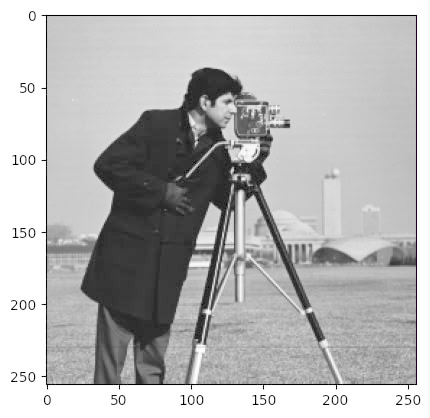

In [38]:

# ── 3. Power-law / Gamma correction ───────────────
img_norm = np.array(img).astype(np.float64) / 255.0

gamma = 0.5   # gamma < 1 brightens the image, gamma > 1 darkens it
c = 1         # scaling constant (1 when r is normalized to [0,1])

gamma_array = c * np.power(img_norm, gamma)
gamma_array = np.clip(gamma_array * 255, 0, 255).astype(np.uint8)

gamma_img = Image.fromarray(gamma_array)
display(gamma_img)
gamma_img.convert("RGB").save("task2_3_gamma.jpg")